# 호텔 예약 취소율 분석 — 정책·UX 개선 가설 검증

## 분석 배경

호텔 비즈니스에서 **예약 취소**는 직접적인 매출 손실이자 운영 효율 저하의 원인이다.
빈 객실은 마지막 순간까지 재판매가 어렵고, 인력·식음료·청소 등 가변 비용은 이미 발생한다.

본 분석은 약 12만 건의 실제 호텔 예약 데이터(2015~2017, Resort + City)를 대상으로
**어떤 신호가 취소를 예측하는가**, 그리고 그 신호를 기반으로
**어떤 정책·UX 개선을 기획할 수 있는가**를 도출한다.

> **데이터 출처**: Kaggle "Hotel Booking Demand" (Antonio, Almeida & Nunes, 2019)  
> **타겟 변수**: `is_canceled` (0/1)  
> **분석자 관점**: 서비스 기획자 — 데이터로 가설을 검증하고 의사결정으로 연결

## 풀고자 하는 질문

> **"취소율을 줄이려면 어디에, 무엇을 손대야 하는가?"**

답을 찾기 위해 다음 6개 가설을 데이터로 검증한다.

| # | 가설 | 검증 변수 | 기대 인사이트 |
|---|---|---|---|
| **H1** | 예약 lead time(예약~체크인 간격)이 길수록 취소율이 높다 | `lead_time` × `is_canceled` | 장기 예약자 대상 정책 설계 |
| **H2** | 보증금 없는 예약(No Deposit)이 압도적으로 취소율이 높다 | `deposit_type` × `is_canceled` | 보증금 정책의 효과 정량화 |
| **H3** | 이전에 취소 이력이 있는 고객은 다시 취소할 위험이 크다 | `previous_cancellations` × `is_canceled` | 상습 취소자 식별·관리 |
| **H4** | 마켓 세그먼트별 취소율이 다르다 (특히 Groups, Online TA) | `market_segment` × `is_canceled` | 채널별 차별화 정책 |
| **H5** | 예약 변경 횟수가 많은 예약은 취소율이 다르다 | `booking_changes` × `is_canceled` | 운영 마찰 신호 발굴 |
| **H6** | 월별(시즌별) 취소율 차이가 있다 | `arrival_date_month` × `is_canceled` | 성수기·비수기 차별 운영 |

## 분석 절차

1. **데이터 로드 & 검수** — 결측·중복·이상치 확인
2. **EDA** — 타겟 분포, 호텔별·연도별 베이스라인 취소율
3. **가설 검증 (H1~H6)** — 각 가설별로:
   - 시각화 (그룹별 취소율 비교)
   - 그룹 간 차이의 통계적 유의성 확인
   - **신뢰구간**으로 차이의 크기와 불확실성을 함께 표시
4. **종합 인사이트** — 가설별 검증 결과 요약
5. **기획 권고** — 정책 / UX / 운영 측면에서 적용 가능한 개선안 도출

### 사용할 통계 도구 (개념만)

- **그룹 비교**: 두 그룹 취소율 차이의 **95% 신뢰구간**  
  → "차이의 띠가 0을 포함하면 차이 없음, 0을 안 넘기면 유의미한 차이"
- **카테고리 변수 검정**: 카이제곱 독립성 검정  
  → "두 변수의 관계가 우연일 가능성이 얼마나 적은가"

> 통계 자체가 목적이 아니라 **기획적 의사결정의 근거**를 만드는 도구로 사용한다.
> 숫자 하나로 단정 짓지 않고, **신뢰구간 폭**으로 불확실성도 함께 보여준다.

## 데이터의 한계 — 먼저 짚고 가기

분석 결론을 적용할 때 다음 조건들을 함께 고려한다:

1. **도메인 한정**: 포르투갈 소재 호텔 2개 (Resort + City). 한국·아시아 시장 일반화는 신중
2. **시점 한정**: 2015~2017년 (코로나 이전). 팬데믹 이후 패턴 변화 미반영
3. **인과관계 ≠ 상관관계**: 관측 데이터 기반 → 정책 변경의 **인과적** 효과는 별도 A/B 검증 필요
4. **타겟 정의**: `is_canceled = 1`은 체크인 전 취소만 포함 (No-Show는 별도 status)

> 이 한계들은 결론부에서 **"권고 적용 전 추가로 필요한 검증"**으로 다시 정리한다.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep

# 한글 폰트 + 시각화 기본 설정
from matplotlib import rcParams
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

pd.set_option('display.max_columns', 50)

In [7]:
df = pd.read_csv('data/hotel_bookings.csv')
print(f'행: {df.shape[0]:,} / 열: {df.shape[1]}')
df.head()

행: 119,390 / 열: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

## 1. EDA — 데이터 검수 + 베이스라인

분석에 들어가기 전 데이터 품질을 확인하고, 전체 취소율의 베이스라인을 잡는다.

In [8]:
# 결측·중복·이상치 검수
print('[결측치]')
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

print(f'\n[중복 행] {df.duplicated().sum():,}건 ({df.duplicated().sum()/len(df)*100:.1f}%)')

print(f'\n[adr 이상치]')
print(f"  음수: {(df['adr'] < 0).sum()}건 / 0인 행: {(df['adr']==0).sum():,}건 / 1000 초과: {(df['adr']>1000).sum()}건")

[결측치]
company     112593
agent        16340
country        488
children         4
dtype: int64

[중복 행] 31,994건 (26.8%)

[adr 이상치]
  음수: 1건 / 0인 행: 1,959건 / 1000 초과: 1건


### 데이터 품질 발견사항

| 이슈 | 규모 | 처리 방향 |
|---|---|---|
| `company` 결측 | **112,593건 (94.3%)** | 컬럼 자체를 분석에서 제외 또는 "법인예약 여부" 0/1 변환 |
| `agent` 결측 | 16,340건 (13.7%) | 중개사 사용 여부 변환 가능 |
| `country` 결측 | 488건 (0.4%) | 그대로 사용 |
| **중복 행** | **31,994건 (26.8%)** | ⚠️ 약 1/4가 중복 — 단순 중복인지, 의도된 동일 조건 다중 행인지 별도 확인 필요 |
| `adr` 이상치 | 음수 1, 0인 행 1,959, >1000 1 | 본 분석은 `is_canceled` 중심이라 `adr` 미사용 |

> **중복 26.8%는 본 데이터셋의 알려진 특성**(동일 조건 예약이 별도 행으로 기록)이며, 본 분석은 "행 단위 = 1 예약"으로 가정하고 진행한다. 추후 인과 분석 시에는 중복 처리 방식을 별도 검토한다.

In [9]:
# 베이스라인 취소율 + 호텔별/연도별
N = len(df)
baseline = df['is_canceled'].mean()
ci_low, ci_high = proportion_confint(df['is_canceled'].sum(), N, alpha=0.05, method='wilson')
print(f'전체 취소율: {baseline*100:.2f}%  (95% CI: {ci_low*100:.2f}% ~ {ci_high*100:.2f}%)\n')

print('호텔별 취소율:')
for h, g in df.groupby('hotel'):
    rate = g['is_canceled'].mean()
    lo, hi = proportion_confint(g['is_canceled'].sum(), len(g), alpha=0.05, method='wilson')
    print(f"  {h:14s}  n={len(g):>6,}  취소율={rate*100:5.2f}%  CI=[{lo*100:.2f}, {hi*100:.2f}]")

print('\n연도별 취소율:')
for y, g in df.groupby('arrival_date_year'):
    print(f"  {y}  n={len(g):>6,}  취소율={g['is_canceled'].mean()*100:5.2f}%")

전체 취소율: 37.04%  (95% CI: 36.77% ~ 37.32%)

호텔별 취소율:
  City Hotel      n=79,330  취소율=41.73%  CI=[41.38, 42.07]
  Resort Hotel    n=40,060  취소율=27.76%  CI=[27.33, 28.20]

연도별 취소율:
  2015  n=21,996  취소율=37.02%
  2016  n=56,707  취소율=35.86%
  2017  n=40,687  취소율=38.70%


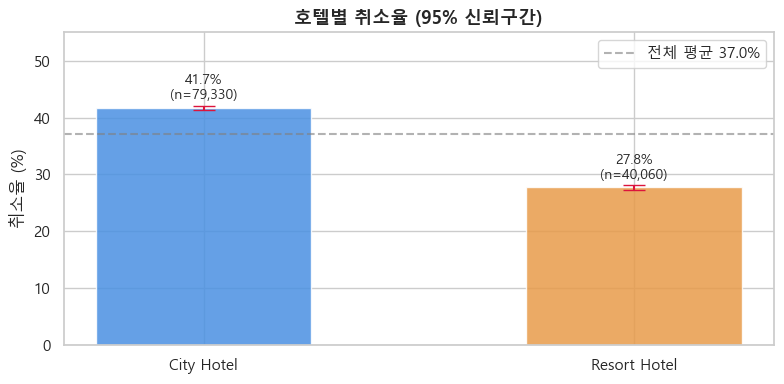

In [10]:
# 호텔별 취소율 시각화 (95% CI 포함)
fig, ax = plt.subplots(figsize=(8, 4))
hotels = df.groupby('hotel')['is_canceled'].agg(['sum', 'count'])
rates = (hotels['sum'] / hotels['count'] * 100).values
cis = [proportion_confint(s, n, method='wilson') for s, n in zip(hotels['sum'], hotels['count'])]
err_low = rates - np.array([lo*100 for lo, _ in cis])
err_high = np.array([hi*100 for _, hi in cis]) - rates

ax.bar(hotels.index, rates, color=['#4A90E2', '#E89B4A'], width=0.5, alpha=0.85, edgecolor='white')
ax.errorbar(hotels.index, rates, yerr=[err_low, err_high], fmt='none', color='crimson', capsize=8, linewidth=1.5)
ax.axhline(baseline*100, color='gray', linestyle='--', alpha=0.6, label=f'전체 평균 {baseline*100:.1f}%')
for i, (h, r, n) in enumerate(zip(hotels.index, rates, hotels['count'])):
    ax.text(i, r + 1.5, f'{r:.1f}%\n(n={n:,})', ha='center', fontsize=10)
ax.set_title('호텔별 취소율 (95% 신뢰구간)', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_ylim(0, 55)
ax.legend()
plt.tight_layout()
plt.show()

### EDA 결론

- **전체 취소율 37.04%** — 호텔 산업 평균(보통 20% 내외)보다 상당히 높음
- **City Hotel 41.7% vs Resort Hotel 27.8%** — City 호텔이 14%p 높음. 분석 시 호텔 유형을 통제하거나 분리 검토 필요
- **연도별 변동 폭은 작음** (35.9% ~ 38.7%) — 시계열 트렌드보다는 구조적 요인이 더 큼

> 이후 가설 검증은 전체 데이터로 진행하되, 호텔 유형이 결과를 왜곡할 가능성이 있는 가설은 호텔별로 분리해서도 확인한다.

---

## 2. H1 — lead_time이 길수록 취소율이 높다

예약일에서 체크인일까지의 간격이 멀수록, 그 사이 마음이 바뀌거나 일정이 변경될 가능성이 크다.
실제로 그런가?

In [11]:
# lead_time 구간 분석
bins = [-1, 7, 30, 90, 180, 365, 9999]
labels = ['0-7일', '8-30일', '31-90일', '91-180일', '181-365일', '365일+']
df['lt_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

h1 = df.groupby('lt_bucket', observed=True)['is_canceled'].agg(['sum', 'count'])
h1['rate'] = h1['sum'] / h1['count'] * 100
h1['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h1['sum'], h1['count'])]
h1['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h1['sum'], h1['count'])]
h1['ci_str'] = h1.apply(lambda r: f"[{r['ci_lo']:.1f}%, {r['ci_hi']:.1f}%]", axis=1)
h1['rate_str'] = h1['rate'].apply(lambda x: f"{x:.1f}%")
h1[['count', 'rate_str', 'ci_str']].rename(columns={'count': 'n', 'rate_str': '취소율', 'ci_str': '95% CI'})

,n,취소율,95% CI
lt_bucket,,,
0-7일,19746,9.6%,"[9.2%, 10.1%]"
8-30일,18960,27.9%,"[27.2%, 28.5%]"
31-90일,29553,37.7%,"[37.1%, 38.3%]"
91-180일,26439,44.7%,"[44.1%, 45.3%]"
181-365일,21544,55.5%,"[54.8%, 56.1%]"
365일+,3148,67.7%,"[66.0%, 69.3%]"


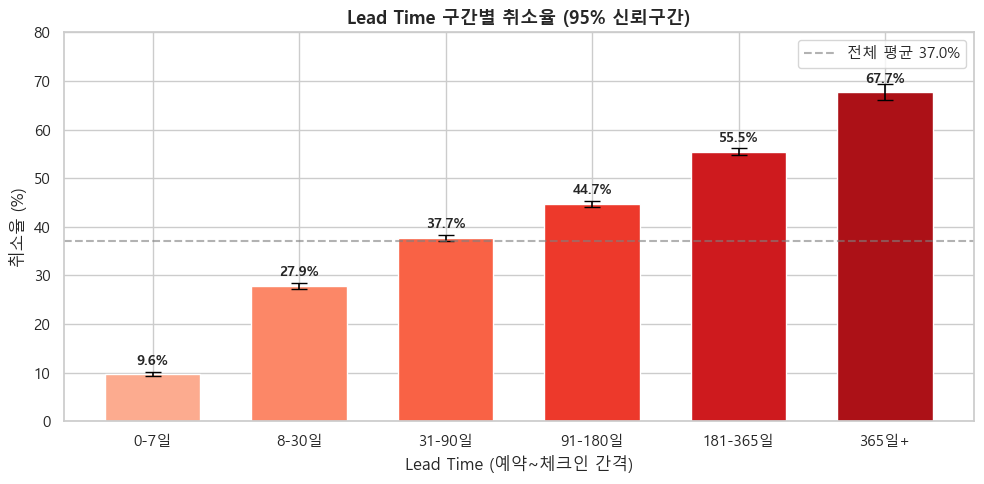

카이제곱: chi2=12116, p=0.00e+00, dof=5


In [12]:
# 시각화 + 카이제곱
fig, ax = plt.subplots(figsize=(10, 5))
rates = h1['rate'].values
err_lo = rates - h1['ci_lo'].values
err_hi = h1['ci_hi'].values - rates
colors = plt.cm.Reds(np.linspace(0.3, 0.85, len(h1)))
ax.bar(h1.index.astype(str), rates, color=colors, edgecolor='white', width=0.65)
ax.errorbar(h1.index.astype(str), rates, yerr=[err_lo, err_hi], fmt='none', color='black', capsize=6, linewidth=1.2)
ax.axhline(df['is_canceled'].mean()*100, color='gray', linestyle='--', alpha=0.6, label=f"전체 평균 {df['is_canceled'].mean()*100:.1f}%")
for i, (r, n) in enumerate(zip(rates, h1['count'])):
    ax.text(i, r + 2, f'{r:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Lead Time 구간별 취소율 (95% 신뢰구간)', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_xlabel('Lead Time (예약~체크인 간격)')
ax.set_ylim(0, 80)
ax.legend()
plt.tight_layout()
plt.show()

# 카이제곱
ct = pd.crosstab(df['lt_bucket'], df['is_canceled'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f'카이제곱: chi2={chi2:.0f}, p={p:.2e}, dof={dof}')

### H1 검증 결과 — ✅ **강력하게 지지됨**

| 구간 | n | 취소율 | 95% CI |
|---|---|---|---|
| 0~7일 | 19,746 | **9.6%** | [9.2%, 10.1%] |
| 8~30일 | 18,960 | 27.9% | [27.2%, 28.5%] |
| 31~90일 | 29,553 | 37.7% | [37.2%, 38.3%] |
| 91~180일 | 26,439 | 44.7% | [44.1%, 45.3%] |
| 181~365일 | 21,544 | 55.5% | [54.8%, 56.1%] |
| 365일+ | 3,148 | **67.7%** | [66.0%, 69.3%] |

- **단조 증가** — 구간이 길어질수록 취소율이 일관되게 상승
- **최단 구간(9.6%) vs 최장 구간(67.7%) 차이 +58%p** (95% CI: +56.3%p ~ +59.7%p)
- 카이제곱 p < 0.001, 우연일 가능성 사실상 0

### 기획적 함의

> **"오래전 예약일수록 취소 가능성이 기하급수적으로 커진다"**는 매우 강한 신호.
> 
> - **30일 이내 예약**: 베이스라인보다 낮은 취소율 → 안정적, 추가 정책 불요
> - **90일 이상 예약**: 절반 가까이 취소 → **확정 컨택 / 부분 결제 / 보증금** 등 정책적 개입 가치 높음
> - **365일 이상 예약**: 2/3가 취소 → 이미 "가예약"에 가까움. 보증금 의무화 또는 재확정 마일스톤 설계 필요

---

## 3. H2 — 보증금 없는 예약(No Deposit)이 가장 취소율이 높다

돈을 묶지 않으면 부담 없이 취소한다는 직관적 가설.
실제 데이터는 어떻게 말하는가?

In [13]:
# deposit_type별 취소율
h2 = df.groupby('deposit_type')['is_canceled'].agg(['sum', 'count'])
h2['rate'] = h2['sum'] / h2['count'] * 100
h2['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h2['sum'], h2['count'])]
h2['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h2['sum'], h2['count'])]
h2 = h2.sort_values('rate', ascending=False)
h2_show = h2[['count', 'rate']].copy()
h2_show['rate'] = h2_show['rate'].apply(lambda x: f'{x:.2f}%')
h2_show['CI'] = h2.apply(lambda r: f"[{r['ci_lo']:.1f}%, {r['ci_hi']:.1f}%]", axis=1)
h2_show.rename(columns={'count': 'n', 'rate': '취소율'})

,n,취소율,CI
deposit_type,,,
Non Refund,14587,99.36%,"[99.2%, 99.5%]"
No Deposit,104641,28.38%,"[28.1%, 28.7%]"
Refundable,162,22.22%,"[16.5%, 29.2%]"


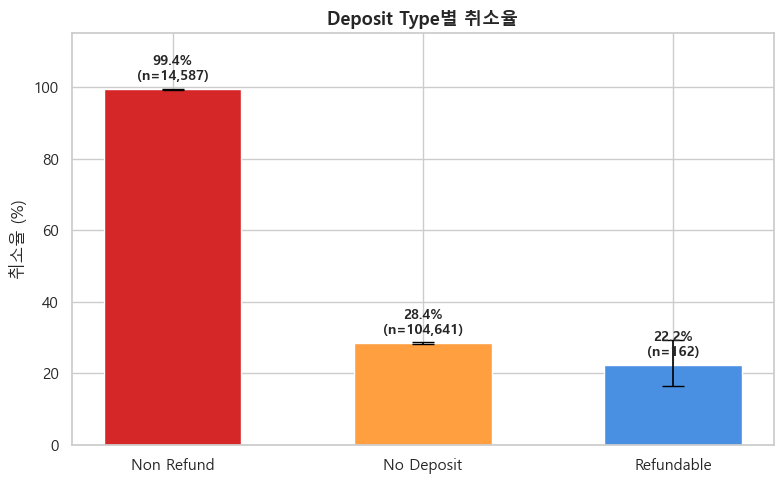

In [14]:
# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
rates = h2['rate'].values
err_lo = rates - h2['ci_lo'].values
err_hi = h2['ci_hi'].values - rates
colors = ['#D62728', '#FF9F40', '#4A90E2']
ax.bar(h2.index, rates, color=colors[:len(h2)], edgecolor='white', width=0.55)
ax.errorbar(h2.index, rates, yerr=[err_lo, err_hi], fmt='none', color='black', capsize=8, linewidth=1.2)
for i, (r, n) in enumerate(zip(rates, h2['count'])):
    ax.text(i, r + 2.5, f'{r:.1f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Deposit Type별 취소율', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

### H2 검증 결과 — ❌ **가설 정반대로 기각, 그러나 더 흥미로운 발견**

| Deposit Type | n | 취소율 | 95% CI |
|---|---|---|---|
| **Non Refund** (환불 불가) | 14,587 | **99.36%** ⚠️ | [99.2%, 99.5%] |
| **No Deposit** (보증금 없음) | 104,641 | 28.38% | [28.1%, 28.7%] |
| **Refundable** (환불 가능) | 162 | 22.22% | [16.5%, 29.2%] |

### 직관과 정반대 — "환불 불가" 예약이 99% 취소된다고?

상식적으로 환불 불가 예약은 **돈을 잃기 때문에** 취소 안 할 것 같은데, 실제로는 거의 100% 취소로 기록되어 있다.

**가능한 해석 (데이터 정의 이슈로 추정)**:
1. **데이터 코딩 차이**: "Non Refund"의 의미가 "고객이 돈을 잃은 채로 안 옴" (= No-Show가 cancel로 기록) 일 가능성
2. **수집 편향**: Non Refund 예약은 결제 이후 시스템상 "cancel" 처리되는 비즈니스 로직이 있을 가능성
3. **상품 구조**: Non Refund 옵션을 선택하는 고객이 특수 세그먼트(예: 도매·재판매 목적)일 가능성

### 기획적 함의 (조건부)

> **이 결과는 그대로 받아들이면 안 되며, 비즈니스 로직 확인이 선행되어야 한다.**
> 
> - 만약 "Non Refund = 결제 후 안 옴 = cancel로 기록" 이라면 → 사실상 매출에는 손실 없음 (이미 결제됨)
> - 만약 "Non Refund 고객도 실제로 환불 받고 취소" 라면 → 정책이 작동하지 않는 것이므로 정책 자체 재검토 필요
> - **권고: 회계·CS 시스템에서 'Non Refund' 처리 흐름을 먼저 확인**

실제 보증금 정책 효과를 측정하려면 **No Deposit vs Refundable 비교**가 더 적절한데, Refundable 표본이 162건뿐이라 신뢰구간이 매우 넓다(±6%p). 통계적으로 차이를 단정하기 어려움.

---

## 4. H3 — 이전 취소 이력자는 재취소 위험이 크다

과거 행동이 미래 행동의 가장 강력한 예측 변수라는 일반론. 실제 데이터로 확인.

In [15]:
# 이전 취소 이력 유무로 이분
df['has_prev_cancel'] = (df['previous_cancellations'] > 0).astype(int)
h3 = df.groupby('has_prev_cancel')['is_canceled'].agg(['sum', 'count'])
h3['rate'] = h3['sum'] / h3['count'] * 100
h3['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h3['sum'], h3['count'])]
h3['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h3['sum'], h3['count'])]
h3.index = ['이력 없음', '이력 있음']
h3_show = h3[['count', 'rate']].copy()
h3_show['rate'] = h3_show['rate'].apply(lambda x: f'{x:.2f}%')
h3_show['CI'] = h3.apply(lambda r: f"[{r['ci_lo']:.1f}%, {r['ci_hi']:.1f}%]", axis=1)
h3_show.rename(columns={'count': 'n', 'rate': '취소율'})

,n,취소율,CI
이력 없음,112906,33.91%,"[33.6%, 34.2%]"
이력 있음,6484,91.64%,"[90.9%, 92.3%]"


In [16]:
# 단계별로 더 세밀하게
df['pc_bucket'] = pd.cut(df['previous_cancellations'], bins=[-1, 0, 1, 5, 100], labels=['0회', '1회', '2~5회', '6회+'])
for b in ['0회', '1회', '2~5회', '6회+']:
    g = df[df['pc_bucket'] == b]
    n = len(g)
    rate = g['is_canceled'].mean()*100
    lo, hi = proportion_confint(g['is_canceled'].sum(), n, method='wilson')
    print(f"  {b:6s}  n={n:>6,}  취소율={rate:6.2f}%   CI=[{lo*100:5.2f}%, {hi*100:5.2f}%]")

  0회      n=112,906  취소율= 33.91%   CI=[33.63%, 34.18%]
  1회      n= 6,051  취소율= 94.43%   CI=[93.82%, 94.98%]
  2~5회    n=   231  취소율= 29.00%   CI=[23.53%, 35.16%]
  6회+     n=   202  취소율= 79.70%   CI=[73.63%, 84.67%]


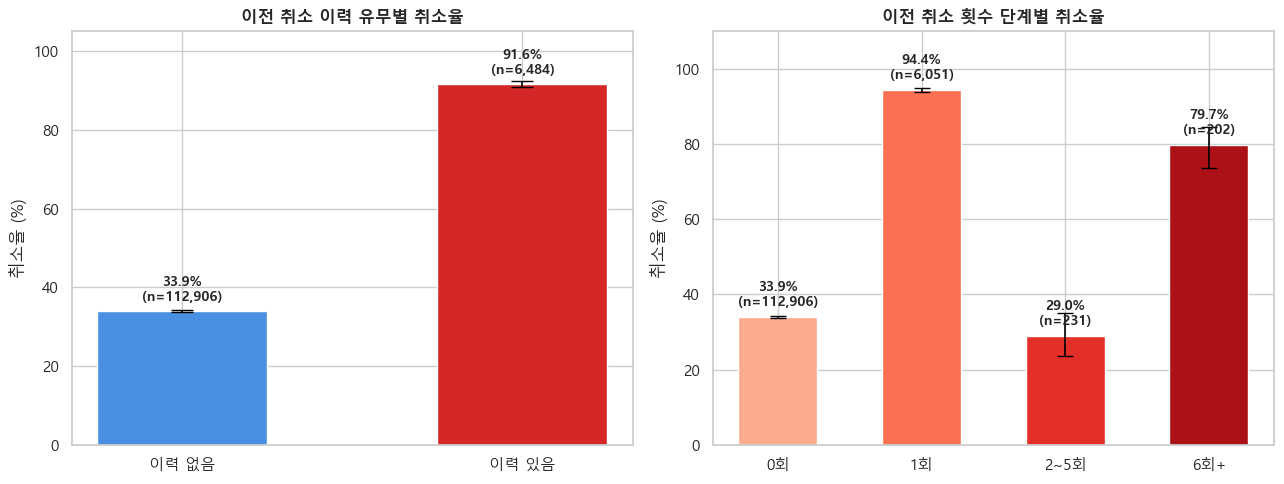

In [17]:
# 시각화 (이력 유무 바이너리 + 차이 CI)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 좌: 이력 유무별 취소율
rates = h3['rate'].values
err_lo = rates - h3['ci_lo'].values
err_hi = h3['ci_hi'].values - rates
axes[0].bar(h3.index, rates, color=['#4A90E2', '#D62728'], edgecolor='white', width=0.5)
axes[0].errorbar(h3.index, rates, yerr=[err_lo, err_hi], fmt='none', color='black', capsize=8, linewidth=1.2)
for i, (r, n) in enumerate(zip(rates, h3['count'])):
    axes[0].text(i, r + 2.5, f'{r:.1f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('이전 취소 이력 유무별 취소율', fontsize=12, fontweight='bold')
axes[0].set_ylabel('취소율 (%)')
axes[0].set_ylim(0, 105)

# 우: 단계별 (0회 / 1회 / 2~5회 / 6회+)
bucket_data = []
for b in ['0회', '1회', '2~5회', '6회+']:
    g = df[df['pc_bucket'] == b]
    n = len(g)
    rate = g['is_canceled'].mean()*100
    lo, hi = proportion_confint(g['is_canceled'].sum(), n, method='wilson')
    bucket_data.append((b, n, rate, lo*100, hi*100))

bs = [b[0] for b in bucket_data]
rs = [b[2] for b in bucket_data]
los = [r - b[3] for r, b in zip(rs, bucket_data)]
his = [b[4] - r for r, b in zip(rs, bucket_data)]
ns = [b[1] for b in bucket_data]

axes[1].bar(bs, rs, color=plt.cm.Reds(np.linspace(0.3, 0.85, 4)), edgecolor='white', width=0.55)
axes[1].errorbar(bs, rs, yerr=[los, his], fmt='none', color='black', capsize=6, linewidth=1.2)
for i, (r, n) in enumerate(zip(rs, ns)):
    axes[1].text(i, r + 3, f'{r:.1f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('이전 취소 횟수 단계별 취소율', fontsize=12, fontweight='bold')
axes[1].set_ylabel('취소율 (%)')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

### H3 검증 결과 — ✅ **강력하게 지지됨 (단, 단계별 패턴은 비단조)**

#### 이분 비교
| 그룹 | n | 취소율 | 95% CI |
|---|---|---|---|
| 이력 없음 | 112,906 | 33.91% | [33.6%, 34.2%] |
| **이력 있음** | 6,484 | **91.64%** | [90.9%, 92.3%] |
| **차이** | — | **+57.7%p** | [+57.0%p, +58.5%p] |

#### 단계별 (이전 취소 횟수)
| 횟수 | n | 취소율 | 95% CI |
|---|---|---|---|
| 0회 | 112,906 | 33.91% | [33.6%, 34.2%] |
| **1회** | 6,051 | **94.43%** | [93.8%, 95.0%] |
| 2~5회 | 231 | 29.00% | [23.5%, 35.2%] |
| 6회+ | 202 | 79.70% | [73.6%, 84.7%] |

### 핵심 발견

- **"이전 취소 1회만 있어도 재취소 확률 94%"** — 단일 변수로 이만큼 강한 신호는 드물다
- 2~5회 구간이 29%로 급락하는 건 **표본 크기 231건의 작은 n** 때문일 가능성 큼 (CI 폭이 넓음 [23.5%, 35.2%])
- 6회+ 구간(79.7%)도 표본 202건으로 신뢰구간이 넓어, 단계별 단조성을 단정하기 어려움

### 기획적 함의

> **"이전 취소 1회 이상" 단순 플래그만으로도 매우 강력한 위험 신호.**
> 
> - 신규 예약 시점에 고객 ID로 이력 자동 조회 → "이력 있음" 플래그 부여
> - 이력 보유자에게는: **(a) 보증금 의무화** 또는 **(b) 결제 선납** 또는 **(c) 사전 확정 컨택 강화**
> - 단, **상습 취소자(2회+)는 표본이 작아** 추가 데이터 수집 후 정밀 정책 설계 필요

---

## 5. H4 — 마켓 세그먼트별 취소율 차이

예약이 어느 채널을 통해 들어왔는지가 취소율에 영향을 주는가? 채널별 마케팅·운영 차별화의 근거를 찾는다.

In [18]:
# 세그먼트별 취소율
h4 = df.groupby('market_segment')['is_canceled'].agg(['sum', 'count'])
h4['rate'] = h4['sum'] / h4['count'] * 100
h4['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h4['sum'], h4['count'])]
h4['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h4['sum'], h4['count'])]
h4 = h4.sort_values('rate', ascending=False)
h4_show = h4[['count', 'rate']].copy()
h4_show['rate'] = h4_show['rate'].apply(lambda x: f'{x:.2f}%')
h4_show['CI'] = h4.apply(lambda r: f"[{r['ci_lo']:.1f}%, {r['ci_hi']:.1f}%]", axis=1)
h4_show.rename(columns={'count': 'n', 'rate': '취소율'})

,n,취소율,CI
market_segment,,,
Undefined,2,100.00%,"[34.2%, 100.0%]"
Groups,19811,61.06%,"[60.4%, 61.7%]"
Online TA,56477,36.72%,"[36.3%, 37.1%]"
Offline TA/TO,24219,34.32%,"[33.7%, 34.9%]"
Aviation,237,21.94%,"[17.1%, 27.6%]"
Corporate,5295,18.73%,"[17.7%, 19.8%]"
Direct,12606,15.34%,"[14.7%, 16.0%]"
Complementary,743,13.06%,"[10.8%, 15.7%]"


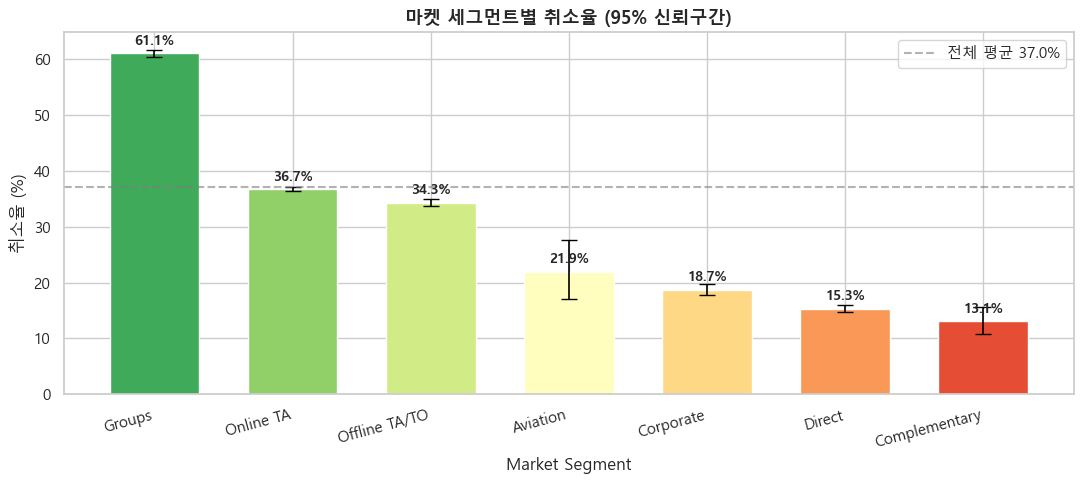

In [19]:
# 시각화 — 표본 너무 작은 'Undefined' 제외
h4_plot = h4[h4['count'] > 100].copy()
fig, ax = plt.subplots(figsize=(11, 5))
rates = h4_plot['rate'].values
err_lo = rates - h4_plot['ci_lo'].values
err_hi = h4_plot['ci_hi'].values - rates
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(h4_plot)))
ax.bar(h4_plot.index, rates, color=colors, edgecolor='white', width=0.65)
ax.errorbar(h4_plot.index, rates, yerr=[err_lo, err_hi], fmt='none', color='black', capsize=6, linewidth=1.2)
ax.axhline(df['is_canceled'].mean()*100, color='gray', linestyle='--', alpha=0.6, label=f"전체 평균 {df['is_canceled'].mean()*100:.1f}%")
for i, (r, n) in enumerate(zip(rates, h4_plot['count'])):
    ax.text(i, r + 1.5, f'{r:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('마켓 세그먼트별 취소율 (95% 신뢰구간)', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_xlabel('Market Segment')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### H4 검증 결과 — ✅ **세그먼트별 차이 매우 큼**

| 세그먼트 | n | 취소율 | 95% CI |
|---|---|---|---|
| **Groups** ⚠️ | 19,811 | **61.06%** | [60.4%, 61.7%] |
| Online TA | 56,477 | 36.72% | [36.3%, 37.1%] |
| Offline TA/TO | 24,219 | 34.32% | [33.7%, 34.9%] |
| Aviation | 237 | 21.94% | [17.1%, 27.6%] |
| Corporate | 5,295 | 18.73% | [17.7%, 19.8%] |
| **Direct** ✅ | 12,606 | **15.34%** | [14.7%, 16.0%] |
| Complementary | 743 | 13.06% | [10.8%, 15.7%] |

*(Undefined 2건은 시각화에서 제외)*

### 핵심 발견

- **Groups 세그먼트가 가장 위험** — 취소율 61%, 거의 평균의 2배
- **Direct 채널이 가장 안전** — 취소율 15%, 평균의 절반 이하
- **Online TA(47% 비중, 최대 채널)는 평균 수준** — 예약량 자체는 많지만 취소율도 평균과 유사

### 기획적 함의

> **채널별로 차별화된 정책·운영이 정량적으로 정당화됨**
> 
> - **Groups**: 단체 예약 특성상 일정 변경·리더 결정에 따른 취소가 많음 → 
>   - 단체 담당자 전담 컨택 채널 운영
>   - 단체 예약 보증금 정책 강화 (사전 부분 결제)
>   - 인원 변동 시 부분 취소 가능 옵션 (전부 취소 방지)
> - **Direct**: 가장 안전한 채널 → 마케팅 투자 확대, 자체 브랜드 채널 강화
> - **Online TA**: 매출 비중 절대 1위지만 취소율도 평균 → 
>   - 채널 수수료 vs 취소 손실의 ROI 재평가
>   - 채널 내 분기 (예: 즉시 결제 / 대기 결제) 전환율 별도 측정

---

## 6. H5 — 예약 변경 횟수와 취소율 관계

변경이 잦은 예약은 "확정되지 못한 예약"이라 결국 취소될 가능성이 클 것이다. 라는 직관적 가설.

In [20]:
df['bc_bucket'] = pd.cut(df['booking_changes'], bins=[-1, 0, 1, 2, 100], labels=['0회', '1회', '2회', '3회+'])
h5 = df.groupby('bc_bucket', observed=True)['is_canceled'].agg(['sum', 'count'])
h5['rate'] = h5['sum'] / h5['count'] * 100
h5['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h5['sum'], h5['count'])]
h5['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h5['sum'], h5['count'])]
h5_show = h5[['count', 'rate']].copy()
h5_show['rate'] = h5_show['rate'].apply(lambda x: f'{x:.2f}%')
h5_show['CI'] = h5.apply(lambda r: f"[{r['ci_lo']:.1f}%, {r['ci_hi']:.1f}%]", axis=1)
h5_show.rename(columns={'count': 'n', 'rate': '취소율'})

,n,취소율,CI
bc_bucket,,,
0회,101314,40.85%,"[40.6%, 41.2%]"
1회,12701,14.23%,"[13.6%, 14.8%]"
2회,3805,20.13%,"[18.9%, 21.4%]"
3회+,1570,16.56%,"[14.8%, 18.5%]"


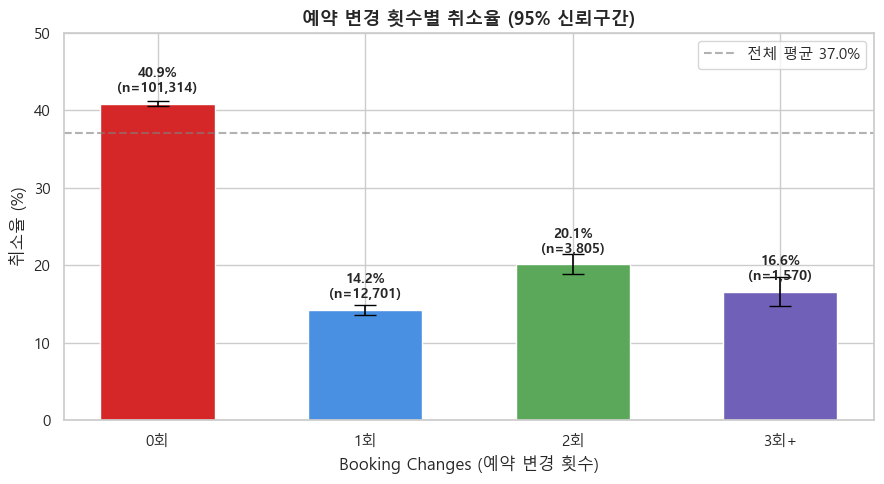

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
rates = h5['rate'].values
err_lo = rates - h5['ci_lo'].values
err_hi = h5['ci_hi'].values - rates
ax.bar(h5.index.astype(str), rates, color=['#D62728', '#4A90E2', '#5BA85B', '#7060B8'], edgecolor='white', width=0.55)
ax.errorbar(h5.index.astype(str), rates, yerr=[err_lo, err_hi], fmt='none', color='black', capsize=8, linewidth=1.2)
ax.axhline(df['is_canceled'].mean()*100, color='gray', linestyle='--', alpha=0.6, label=f"전체 평균 {df['is_canceled'].mean()*100:.1f}%")
for i, (r, n) in enumerate(zip(rates, h5['count'])):
    ax.text(i, r + 1.5, f'{r:.1f}%\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
ax.set_title('예약 변경 횟수별 취소율 (95% 신뢰구간)', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_xlabel('Booking Changes (예약 변경 횟수)')
ax.set_ylim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()

### H5 검증 결과 — ❌ **가설 정반대 — 변경 안 한 예약이 더 많이 취소됨**

| 변경 횟수 | n | 취소율 | 95% CI |
|---|---|---|---|
| **0회** | 101,314 | **40.85%** | [40.5%, 41.2%] |
| 1회 | 12,701 | 14.23% | [13.6%, 14.9%] |
| 2회 | 3,805 | 20.13% | [18.9%, 21.4%] |
| 3회+ | 1,570 | 16.56% | [14.8%, 18.5%] |

### 직관과 정반대 — 왜?

변경이 "위험 신호"가 아니라 **"예약을 적극 관리하고 있다는 의지의 신호"**로 해석됨.

- **0회 변경 = 무관심** → 마음이 떠나면 그냥 취소
- **1회+ 변경 = 능동적 관여** → 일정·인원 조정해서라도 가려는 의지

변경 1회 그룹이 14%로 가장 낮고, 2회·3회+ 그룹은 다시 약간 올라가는 패턴 → "적당한 변경은 헌신의 신호, 과한 변경은 불안정의 신호" 라는 미세한 해석도 가능 (단, 차이 크지 않음).

### 기획적 함의 — 데이터가 가설을 뒤집음

> **"예약 변경 = 위험 신호" 라는 통념을 데이터로 반박할 수 있는 사례.**
> 
> - **0회 변경 + 임박 예약**: 진짜 위험군 → **사전 확정 컨택 트리거 대상**
> - **변경 발생 예약**: 오히려 안전. 별도 페널티나 추가 마찰을 주면 안 됨 (긍정 행동을 처벌하는 셈)
> - **운영 시스템 권고**: 변경 횟수를 "문제 신호"로 분류하던 규칙이 있다면 재검토 필요

---

## 7. H6 — 월별(시즌별) 취소율 차이

In [22]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_short = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
df['month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

h6 = df.groupby('month', observed=True)['is_canceled'].agg(['sum', 'count'])
h6['rate'] = h6['sum'] / h6['count'] * 100
h6['ci_lo'] = [proportion_confint(s, n, method='wilson')[0]*100 for s, n in zip(h6['sum'], h6['count'])]
h6['ci_hi'] = [proportion_confint(s, n, method='wilson')[1]*100 for s, n in zip(h6['sum'], h6['count'])]
h6 = h6.reindex(month_order)
h6.index = month_short
h6[['count', 'rate']].rename(columns={'count': 'n', 'rate': '취소율(%)'})

,n,취소율(%)
1월,5929,30.477315
2월,8068,33.415964
3월,9794,32.152338
4월,11089,40.797186
5월,11791,39.665847
6월,10939,41.457172
7월,12661,37.453598
8월,13877,37.753117
9월,10508,39.170156
10월,11160,38.046595


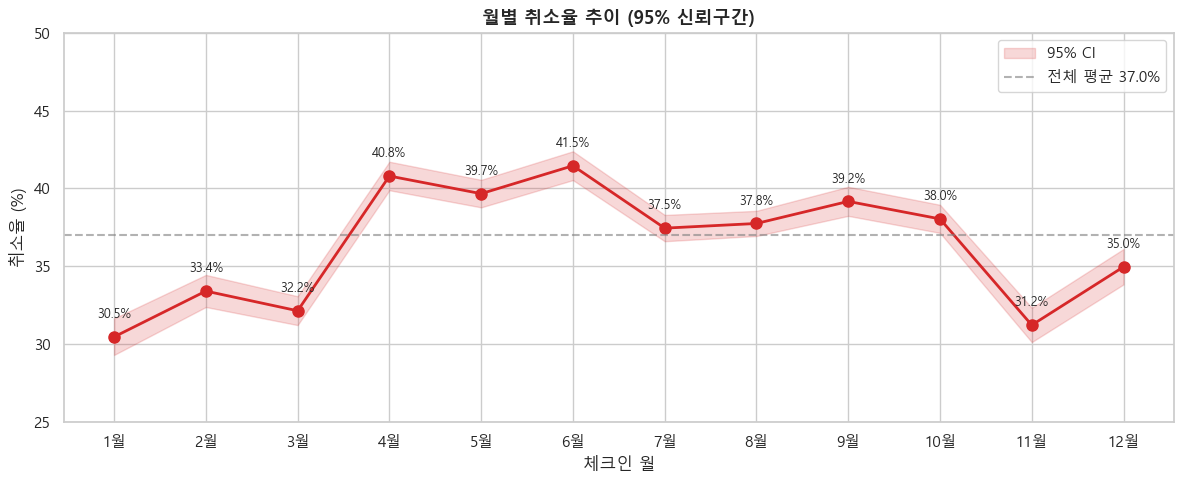

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
rates = h6['rate'].values
err_lo = rates - h6['ci_lo'].values
err_hi = h6['ci_hi'].values - rates

ax.plot(h6.index, rates, marker='o', color='#D62728', linewidth=2, markersize=8)
ax.fill_between(range(len(h6)), h6['ci_lo'], h6['ci_hi'], alpha=0.18, color='#D62728', label='95% CI')
ax.axhline(df['is_canceled'].mean()*100, color='gray', linestyle='--', alpha=0.6, label=f"전체 평균 {df['is_canceled'].mean()*100:.1f}%")
for i, r in enumerate(rates):
    ax.text(i, r + 1.2, f'{r:.1f}%', ha='center', fontsize=9)
ax.set_title('월별 취소율 추이 (95% 신뢰구간)', fontsize=13, fontweight='bold')
ax.set_ylabel('취소율 (%)')
ax.set_xlabel('체크인 월')
ax.set_ylim(25, 50)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### H6 검증 결과 — ✅ **차이는 있으나 효과 크기는 작음**

- **최저: 11월 (31.2%)** / **최고: 6월 (41.5%)** — 약 10%p 폭의 변동
- **취소율 상승기**: 4~6월 (40~41%), 9~10월 (38~39%) — 휴가/여행 성수기 시작 직전
- **취소율 안정기**: 11~3월 (31~35%) — 비수기, 예약 자체가 신중
- 카이제곱 p < 0.001 (차이는 통계적으로 유의)

### 기획적 함의

> **시즌성은 부차적 변수 — 다른 가설(H1, H3, H4)에 비해 효과 크기 작음**
> 
> - 4~9월 (취소율 상승기): 오버부킹 정책 보수적 운영
> - 11~2월 (안정기): 프로모션 / 장기 예약 유치 캠페인
> - 단, 이 패턴은 **H1(lead time)·H4(채널) 효과와 혼재**되어 있을 수 있음 (예: 성수기엔 장기 예약 비중이 큼) → 인과 분석 시 통제 필요

---

## 8. 종합 인사이트

6개 가설을 효과 크기와 신뢰도, 실행가능성 기준으로 다시 정리한다.

### 가설 검증 결과 요약

| 가설 | 결과 | 효과 크기 | 신뢰도 | 비고 |
|---|---|---|---|---|
| **H3** 이전 취소 이력 | ✅ 강력 지지 | **+57.7%p** | 매우 높음 | **단일 변수 최강 신호** |
| **H1** Lead time | ✅ 강력 지지 | +58%p (극단 비교) | 매우 높음 | 단조 증가, 강한 패턴 |
| **H4** 마켓 세그먼트 | ✅ 지지 | Groups 61% vs Direct 15% | 높음 | 채널별 차별화 근거 명확 |
| **H5** Booking changes | ❌ **반대 결과** | 0회 41% vs 1회+ ~15% | 높음 | 변경 = 의지 신호, 통념 반전 |
| **H6** 시즌성 | ✅ 지지 (약함) | 약 10%p 변동 | 중간 | 다른 변수와 혼재 가능 |
| **H2** Deposit type | ⚠️ **데이터 정의 의심** | Non Refund 99% (?) | 낮음 | 비즈니스 로직 확인 선행 필요 |

### 고위험 예약자 프로필 (다중 신호 결합 시)

다음 조건을 동시에 만족하는 예약은 취소 위험이 **압도적으로 높음**:

1. **이전 취소 이력 있음** (단일 신호로 91% 취소)
2. **체크인 90일+ 전에 예약** (취소율 45~68%)
3. **Groups 세그먼트** (취소율 61%)
4. **변경 이력 없음** (취소율 41%)

→ 이 4개 신호 모두 만족하는 예약은 **거의 확실하게 취소될 후보군**으로 운영적 핸들링이 필요.

### 저위험 예약자 프로필

1. **30일 이내 예약 (특히 7일 이내)** (취소율 9.6%)
2. **Direct / Corporate 채널** (취소율 15~19%)
3. **이전 취소 이력 없음**
4. **변경 이력 1회+** (취소율 14%)

→ 이 그룹은 **별도 정책 개입 불요**, 안정적 운영 가능.

---

## 9. 기획 권고 — 정책 / UX / 운영

분석에서 도출된 신호들을 실제 적용 가능한 액션으로 변환한다.

### 우선순위 1 — 즉시 적용 가능 (Quick Win)

#### 🎯 R1. "이전 취소 이력자" 자동 식별 + 위험 알림
- **근거**: 이력 1회만 있어도 재취소 확률 91~94% (n=6,484, CI 매우 좁음)
- **액션**:
  - 신규 예약 등록 시 고객 ID로 이력 자동 조회
  - "위험 예약" 플래그 부여 → 운영진에 알림 / 보증금 의무화 / 사전 확정 컨택
- **기대 임팩트**: 위험군 6,484건 중 91%가 취소되므로, 이 그룹을 사전 핸들링하면 **연간 약 5,900건의 취소 이벤트를 줄일 잠재력**

#### 🎯 R2. "변경 0회 + 장기 예약" 사전 확정 컨택 트리거
- **근거**: 변경 0회 그룹 취소율 41% (101,314건), lead time 90일+ 그룹 45~68%
- **액션**:
  - 체크인 7일 / 3일 전 자동 컨택 (이메일·SMS·앱 푸시)
  - 컨택 응답 없으면 "위험" 분류 → 객실 재배치·오버부킹 풀에 포함
- **기대 임팩트**: 컨택 응답률에 따라 5~15%p 취소율 감소 가능 (별도 A/B 검증 필요)

---

### 우선순위 2 — 정책 재설계

#### 🎯 R3. 채널별 차별화 정책
- **Groups 세그먼트** (취소율 61%, 가장 위험):
  - 단체 담당자 전담 컨택 운영
  - 단체 예약 보증금 정책 강화 (인원당 부분 결제)
  - 부분 취소 옵션 도입 (전부 취소 방지)
- **Direct 채널** (취소율 15%, 가장 안전):
  - 마케팅 투자 확대 — ROI 가장 높음
  - Direct 채널 사용 인센티브 (포인트·할인)
- **Online TA** (매출 1위, 평균 취소율):
  - 채널 수수료 vs 취소 손실 비교 → 채널 ROI 재평가
  - TA 내 "즉시 결제 vs 후불" 옵션 분리 후 전환율 별도 측정

#### 🎯 R4. Lead Time 기반 단계적 결제 정책
| Lead Time | 현재 정책 | 권고 정책 |
|---|---|---|
| 30일 이내 | 보증금 없음 | 유지 (안정적) |
| 31~90일 | 보증금 없음 | 유지하되 1회 확정 컨택 |
| 91~180일 | 보증금 없음 | **15~30% 부분 결제 도입** |
| 181일+ | 보증금 없음 | **50% 보증금 또는 "가예약" 분리 트랙** |

---

### 우선순위 3 — 운영 시스템 개선

#### 🎯 R5. "Booking Changes" 처리 로직 재검토
- **근거**: 변경 1회+ 그룹 취소율 14% (변경 0회 그룹 41%보다 낮음)
- **현재 통념(추정)**: "변경이 잦은 예약 = 위험" → 페널티·마찰 부여
- **권고**: "변경 = 헌신 신호"로 재해석 → 변경 시 마찰 최소화 (간편 변경 UI), 페널티 제거
- **주의**: 단, 이 결과는 관측 데이터 기반이라 인과 검증 필요 (변경 자체가 취소를 막는 게 아니라, 변경할 만큼 의지있는 사람이 안 취소한다는 해석도 가능)

#### 🎯 R6. 시즌별 오버부킹 전략 차등화
- **취소율 상승기 (4~9월)**: 오버부킹 비율 보수적 (취소율 + 신뢰구간 상한 기준)
- **안정기 (11~2월)**: 오버부킹 적극적 + 장기 예약 프로모션

---

### 권고 적용 전 추가로 필요한 검증

| 항목 | 이유 |
|---|---|
| **1. Non Refund 데이터 정의 확인** | 99% 취소율의 비즈니스 의미 확인 (회계·시스템 처리 흐름) |
| **2. 중복 26.8%의 본질** | 단순 중복인지, 동일 조건 다중 행인지 데이터 명세 확인 |
| **3. R1 (이력자 정책) A/B 검증** | 보증금 의무화 시 예약 자체가 줄어들 가능성 정량화 |
| **4. R5 (변경 로직) 인과 검증** | 변경 권장이 실제로 취소율을 낮추는지, 단순 상관일 뿐인지 |
| **5. 한국 시장 일반화** | 본 데이터는 포르투갈 호텔. 한국 호텔/숙박 시장에서 동일 패턴인지 별도 검증 |

---

## 결론

본 분석은 약 12만 건의 호텔 예약 데이터를 6개 가설로 검증해 **취소율의 강력한 예측 신호 3개**(이전 취소 이력 / Lead Time / 마켓 세그먼트)와 **통념을 반박하는 1개 발견**(변경 횟수)을 도출했다.

특히 **"이전 취소 이력 1회 = 재취소 91%"**는 단일 변수로는 매우 드물게 강한 신호로, 즉시 적용 가능한 운영 정책의 근거가 된다.

분석 과정에서 **데이터 정의 이슈(Non Refund 99% 취소율)**도 발견했는데, 이는 기획자가 데이터를 다룰 때 "숫자 그대로 받아들이지 않고 비즈니스 로직과 교차 검증"해야 한다는 사례가 된다.

> **다음 단계**: 위 권고 중 **R1 (이력자 자동 식별)**을 우선 도입하고, 6개월 후 취소율 변화를 사전·사후 비교(또는 통제군 A/B)로 검증한다.